In [1]:
import sqlite3

In [3]:
# Connecting to the SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [4]:
# Drop table if already exists (for repeatability)
cursor.execute("DROP TABLE IF EXISTS sales")

# Creating a 'sales' table
cursor.execute('''
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        date TEXT NOT NULL,
        product TEXT NOT NULL,
        region TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

In [5]:
# Inserting sample data
sales_data = [
    ('2025-01-01', 'Shirt', 'North', 5, 20.0),
    ('2025-01-02', 'Pants', 'South', 3, 35.0),
    ('2025-01-03', 'Shirt', 'East', 2, 20.0),
    ('2025-01-04', 'Shoes', 'North', 4, 50.0),
    ('2025-01-05', 'Hat', 'West', 6, 15.0),
    ('2025-01-06', 'Pants', 'North', 7, 35.0),
    ('2025-01-07', 'Shoes', 'East', 2, 50.0),
    ('2025-01-08', 'Shirt', 'South', 4, 20.0),
    ('2025-01-09', 'Hat', 'South', 5, 15.0),
    ('2025-01-10', 'Shoes', 'West', 3, 50.0),
    ('2025-01-11', 'Pants', 'East', 4, 35.0),
    ('2025-01-12', 'Shirt', 'West', 3, 20.0)
]

cursor.executemany("INSERT INTO sales (date, product, region, quantity, price) VALUES (?, ?, ?, ?, ?)", sales_data)

In [9]:
conn.commit()

## Data Analysis with SQL & Pandas

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

In [14]:
os.makedirs("sales_charts", exist_ok=True)

In [24]:
# Query 1: Total revenue and quantity by product
query1 = '''
    SELECT product, 
           SUM(quantity) AS total_quantity, 
           SUM(quantity * price) AS total_revenue
    FROM sales
    GROUP BY product
'''
df_product_summary = pd.read_sql_query(query1, conn)
print("\nProduct Summary:\n") 
df_product_summary


Product Summary:



,product,total_quantity,total_revenue
0,Hat,11,165.0
1,Pants,14,490.0
2,Shirt,14,280.0
3,Shoes,9,450.0


In [26]:
# Query 2: Revenue by region
query2 = '''
    SELECT region, 
           SUM(quantity * price) AS total_revenue
    FROM sales
    GROUP BY region
'''
df_region_revenue = pd.read_sql_query(query2, conn)
print("\nRevenue by Region:\n")
df_region_revenue


Revenue by Region:



,region,total_revenue
0,East,280.0
1,North,545.0
2,South,260.0
3,West,300.0


In [28]:
# Query 3: Best-selling product by quantity
query3 = '''
    SELECT product, SUM(quantity) AS total_quantity
    FROM sales
    GROUP BY product
    ORDER BY total_quantity DESC
    LIMIT 1
'''
best_seller = pd.read_sql_query(query3, conn)
print("\nBest Selling Product:\n")
best_seller


Best Selling Product:



,product,total_quantity
0,Shirt,14


In [30]:
# Query 4: Sales trend by day
query4 = '''
    SELECT date, SUM(quantity * price) AS daily_revenue
    FROM sales
    GROUP BY date
    ORDER BY date
'''
df_daily_sales = pd.read_sql_query(query4, conn)
print("\nDaily Revenue:\n")
df_daily_sales


Daily Revenue:



,date,daily_revenue
0,2025-01-01,100.0
1,2025-01-02,105.0
2,2025-01-03,40.0
3,2025-01-04,200.0
4,2025-01-05,90.0
5,2025-01-06,245.0
6,2025-01-07,100.0
7,2025-01-08,80.0
8,2025-01-09,75.0
9,2025-01-10,150.0


## Visualization

<Figure size 800x500 with 0 Axes>

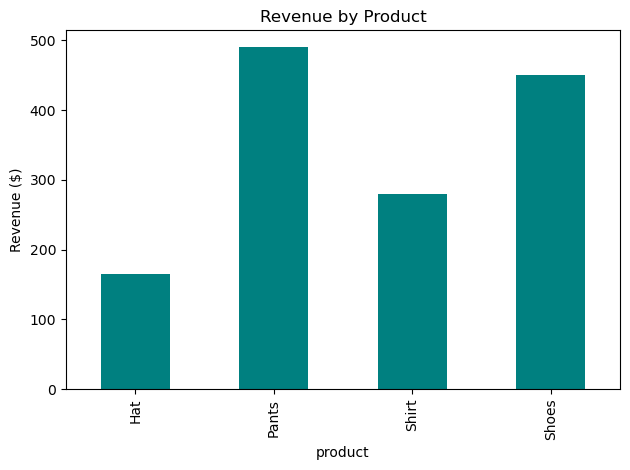

In [33]:
# Bar chart: Revenue by Product
plt.figure(figsize=(8, 5))
df_product_summary.plot(kind='bar', x='product', y='total_revenue', legend=False, color='teal')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_charts/revenue_by_product.png")
plt.show()

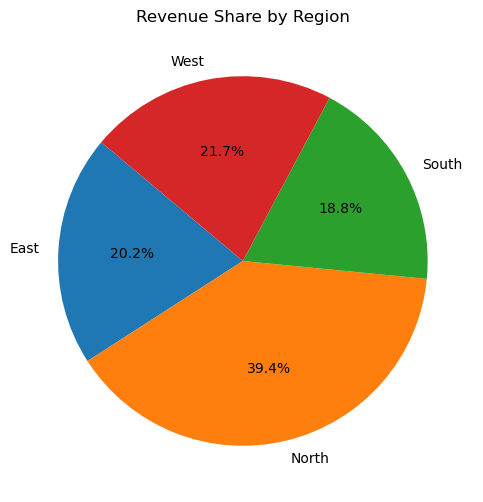

In [35]:
# Pie chart: Revenue by Region
plt.figure(figsize=(6, 6))
plt.pie(df_region_revenue['total_revenue'], labels=df_region_revenue['region'], autopct='%1.1f%%', startangle=140)
plt.title("Revenue Share by Region")
plt.savefig("sales_charts/revenue_by_region.png")
plt.show()

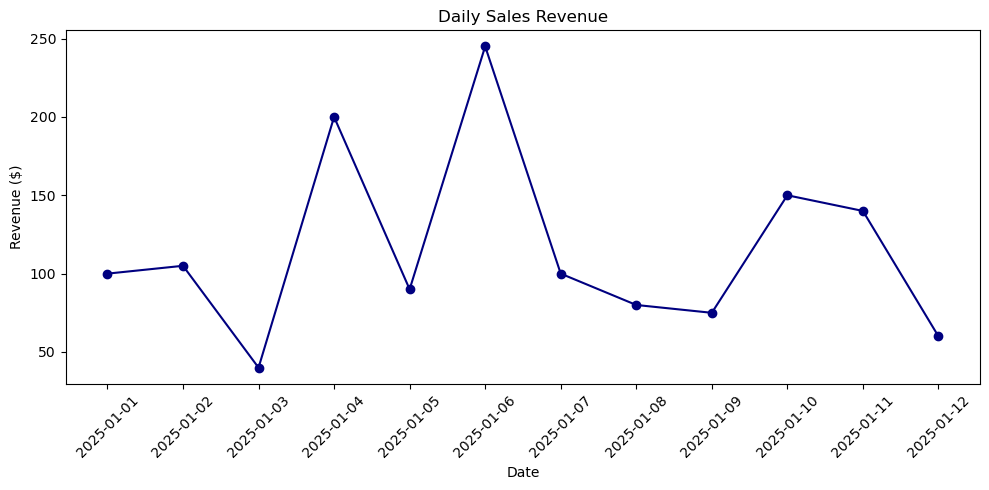

In [37]:
# Line chart: Revenue over Time
plt.figure(figsize=(10, 5))
plt.plot(df_daily_sales['date'], df_daily_sales['daily_revenue'], marker='o', linestyle='-', color='navy')
plt.title("Daily Sales Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_charts/daily_revenue_trend.png")
plt.show()

In [41]:
conn.commit()
conn.close()